In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

file_path = PROJECT_ROOT / "data" / "raw" / "market_data_raw.csv"
df = pd.read_csv(
    file_path,
    header=[0, 1],
    index_col=0
)

df.head()

Ticker            MSFT                                                  \
Price             Open        High         Low       Close      Volume   
Date                                                                     
2020-01-01         NaN         NaN         NaN         NaN         NaN   
2020-01-02  150.090248  151.933525  149.664878  151.829544  22622100.0   
2020-01-03  149.655456  151.196239  149.409676  149.939026  21116200.0   
2020-01-06  148.483307  150.392760  147.944495  150.326584  20813700.0   
2020-01-07  150.600649  150.931485  148.710106  148.955872  21634100.0   

Ticker      EURUSD=X                                       ...   ^VIX  \
Price           Open      High       Low     Close Volume  ...   Open   
Date                                                       ...          
2020-01-01  1.122083  1.122838  1.115947  1.122083    0.0  ...    NaN   
2020-01-02  1.121894  1.122712  1.116682  1.122083    0.0  ...  13.46   
2020-01-03  1.117081  1.118068  1.112570  1.117144    0.0  ...  15.01   
2020-01-06  1.116246  1.120825  1.115810  1.116196    0.0  ...  15.45   
2020-01-07  1.119583  1.119946  1.113487  1.119799    0.0  ...  13.84   

Ticker                                           AAPL                        \
Price            High    Low  Close Volume       Open       High        Low   
Date                                                                          
2020-01-01        NaN    NaN    NaN    NaN        NaN        NaN        NaN   
2020-01-02  13.720000  12.42  12.47    0.0  71.282568  72.331694  71.029915   
2020-01-03  16.200001  13.13  14.02    0.0  71.501542  72.326882  71.345137   
2020-01-06  16.389999  13.54  13.85    0.0  70.693073  72.177722  70.442821   
2020-01-07  14.460000  13.39  13.79    0.0  72.148812  72.403874  71.580942   

Ticker                              
Price           Close       Volume  
Date                                
2020-01-01        NaN          NaN  
2020-01-02  72.271538  135480400.0  
2020-01-03  71.568916  146322800.0  
2020-01-06  72.139221  118387200.0  
2020-01-07  71.799911  108872000.0  

[5 rows x 25 columns]

In [2]:
df.shape

(1562, 25)

In [3]:
df.index[:5]

Index(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07'], dtype='str', name='Date')

In [4]:
df.index[-5:]

Index(['2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29', '2025-12-30'], dtype='str', name='Date')

In [5]:
df.isna().sum()

Ticker    Price 
MSFT      Open      55
          High      55
          Low       55
          Close     55
          Volume    55
EURUSD=X  Open       1
          High       1
          Low        1
          Close      1
          Volume     1
SPY       Open      55
          High      55
          Low       55
          Close     55
          Volume    55
^VIX      Open      55
          High      55
          Low       55
          Close     55
          Volume    55
AAPL      Open      55
          High      55
          Low       55
          Close     55
          Volume    55
dtype: int64

In [6]:
df.index.duplicated().sum()

np.int64(0)

In [7]:
df["AAPL"]["Close"].head(10)

Date
2020-01-01          NaN
2020-01-02    72.271538
2020-01-03    71.568916
2020-01-06    72.139221
2020-01-07    71.799911
2020-01-08    72.954918
2020-01-09    74.504555
2020-01-10    74.672966
2020-01-13    76.268303
2020-01-14    75.238441
Name: Close, dtype: float64

In [8]:
df["SPY"]["Close"].head(10)

Date
2020-01-01           NaN
2020-01-02    296.125214
2020-01-03    293.882935
2020-01-06    295.004150
2020-01-07    294.174683
2020-01-08    295.742523
2020-01-09    297.747772
2020-01-10    296.890961
2020-01-13    298.932800
2020-01-14    298.477142
Name: Close, dtype: float64

In [9]:
df["MSFT"]["Close"].head(10)

Date
2020-01-01           NaN
2020-01-02    151.829544
2020-01-03    149.939026
2020-01-06    150.326584
2020-01-07    148.955872
2020-01-08    151.328568
2020-01-09    153.219086
2020-01-10    152.510132
2020-01-13    154.343994
2020-01-14    153.256973
Name: Close, dtype: float64

In [10]:
prices = df.xs("Close", axis=1, level=1)

prices.head()

Ticker,MSFT,EURUSD=X,SPY,^VIX,AAPL
Date,,,,,
2020-01-01,NaN,1.122083,NaN,NaN,NaN
2020-01-02,151.829544,1.122083,296.125214,12.47,72.271538
2020-01-03,149.939026,1.117144,293.882935,14.02,71.568916
2020-01-06,150.326584,1.116196,295.004150,13.85,72.139221
2020-01-07,148.955872,1.119799,294.174683,13.79,71.799911


In [11]:
returns = prices.pct_change()

returns.head()

Ticker,MSFT,EURUSD=X,SPY,^VIX,AAPL
Date,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN
2020-01-02,NaN,0.000000,NaN,NaN,NaN
2020-01-03,-0.012452,-0.004401,-0.007572,0.124298,-0.009722
2020-01-06,0.002585,-0.000848,0.003815,-0.012126,0.007969
2020-01-07,-0.009118,0.003228,-0.002812,-0.004332,-0.004704


In [12]:
returns.describe()

Ticker,MSFT,EURUSD=X,SPY,^VIX,AAPL
count,1452.000000,1559.000000,1452.000000,1452.000000,1452.000000
mean,0.001011,0.000035,0.000717,0.001526,0.001272
std,0.018760,0.004716,0.013165,0.083293,0.020017
min,-0.147390,-0.027752,-0.109424,-0.357539,-0.128647
25%,-0.007924,-0.002638,-0.004602,-0.042915,-0.007834
50%,0.001183,-0.000100,0.001134,-0.008911,0.001270
75%,0.010494,0.002851,0.006933,0.033235,0.011506
max,0.142169,0.027919,0.105020,0.740391,0.153289


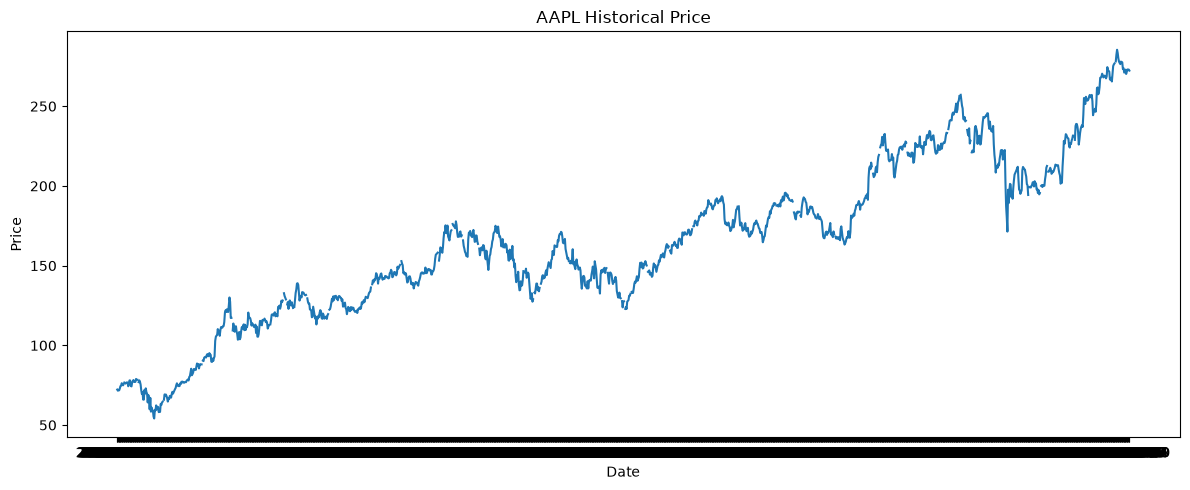

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    prices.index,
    prices["AAPL"],
)

plt.title("AAPL Historical Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [14]:
annualized_volatility = returns.std() * (252 ** 0.5)

annualized_volatility



Ticker
MSFT        0.297805
EURUSD=X    0.074866
SPY         0.208992
^VIX        1.322236
AAPL        0.317756
dtype: float64

In [15]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

MARKET_FACTOR_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "market_factors.parquet"
)

market = pd.read_parquet(
    MARKET_FACTOR_FILE
)

market.head()

,AAPL,SPY,MSFT,EURUSD,VIX,US2Y,US5Y,US10Y
Date,,,,,,,,
2020-01-02,72.271538,296.125275,151.829529,1.122083,12.47,1.58,1.67,1.88
2020-01-03,71.568932,293.882965,149.938995,1.117144,14.02,1.53,1.59,1.80
2020-01-06,72.139183,295.004150,150.326584,1.116196,13.85,1.54,1.61,1.81
2020-01-07,71.799911,294.174683,148.955902,1.119799,13.79,1.54,1.62,1.83
2020-01-08,72.954926,295.742523,151.328613,1.115474,13.45,1.58,1.67,1.87


In [16]:
market.shape


(1495, 8)

In [17]:
market.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1495 entries, 2020-01-02 to 2025-12-30
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1495 non-null   float64
 1   SPY     1495 non-null   float64
 2   MSFT    1495 non-null   float64
 3   EURUSD  1495 non-null   float64
 4   VIX     1495 non-null   float64
 5   US2Y    1495 non-null   float64
 6   US5Y    1495 non-null   float64
 7   US10Y   1495 non-null   float64
dtypes: float64(8)
memory usage: 105.1 KB


In [18]:
market.describe()

,AAPL,SPY,MSFT,EURUSD,VIX,US2Y,US5Y,US10Y
count,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,164.306852,438.127662,314.482673,1.112239,21.001933,2.729057,2.743993,2.952107
std,49.494802,108.141963,100.637300,0.057362,7.917970,1.863445,1.571135,1.407491
min,54.117035,204.418243,128.358353,0.959619,11.860000,0.090000,0.190000,0.520000
25%,131.016273,367.609329,234.873260,1.074460,15.935000,0.270000,0.880000,1.540000
50%,162.902206,413.853851,292.931305,1.099759,19.059999,3.590000,3.590000,3.570000
75%,196.029274,520.644836,404.891800,1.164232,24.110001,4.300000,4.060000,4.200000
max,285.413116,686.730530,538.658508,1.234111,82.690002,5.190000,4.950000,4.980000


In [19]:
market.tail()

,AAPL,SPY,MSFT,EURUSD,VIX,US2Y,US5Y,US10Y
Date,,,,,,,,
2025-12-23,271.620667,684.323303,484.691559,1.176595,14.00,3.48,3.72,4.18
2025-12-24,273.066742,686.730530,485.856323,1.179551,13.47,3.47,3.70,4.15
2025-12-26,272.657806,686.660889,485.547729,1.178536,13.60,3.46,3.68,4.14
2025-12-29,273.016876,684.213867,484.940430,1.177274,14.20,3.45,3.67,4.12
2025-12-30,272.338684,683.378357,485.318756,1.177288,14.33,3.45,3.68,4.14


In [20]:
market.isna().sum()

AAPL      0
SPY       0
MSFT      0
EURUSD    0
VIX       0
US2Y      0
US5Y      0
US10Y     0
dtype: int64

In [21]:
market.index.duplicated().sum()

np.int64(0)

In [22]:
market.index.is_monotonic_increasing

True

In [23]:
PRICE_FACTORS = [
    "AAPL",
    "SPY",
    "MSFT",
    "EURUSD",
]

price_returns = (
    market[PRICE_FACTORS]
    .pct_change()
)

price_returns.head()

,AAPL,SPY,MSFT,EURUSD
Date,,,,
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.007572,-0.012452,-0.004401
2020-01-06,0.007968,0.003815,0.002585,-0.000848
2020-01-07,-0.004703,-0.002812,-0.009118,0.003228
2020-01-08,0.016087,0.005330,0.015929,-0.003863


In [24]:
vix_change = (
    market["VIX"]
    .diff()
)

vix_change.describe()

count    1494.000000
mean        0.001245
std         2.234938
min       -18.710003
25%        -0.830000
50%        -0.150000
75%         0.647500
max        24.860001
Name: VIX, dtype: float64

In [25]:
RATE_FACTORS = [
    "US2Y",
    "US5Y",
    "US10Y",
]

rate_changes = (
    market[RATE_FACTORS]
    .diff()
)

rate_changes.describe()

,US2Y,US5Y,US10Y
count,1494.000000,1494.000000,1494.000000
mean,0.001252,0.001345,0.001513
std,0.063367,0.064781,0.060999
min,-0.570000,-0.320000,-0.300000
25%,-0.020000,-0.030000,-0.030000
50%,0.000000,0.000000,0.000000
75%,0.030000,0.037500,0.040000
max,0.340000,0.310000,0.290000


In [26]:
rate_changes_bps = (
    rate_changes * 100
)

rate_changes_bps.head()

,US2Y,US5Y,US10Y
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-5.0,-8.0,-8.0
2020-01-06,1.0,2.0,1.0
2020-01-07,0.0,1.0,2.0
2020-01-08,4.0,5.0,4.0


In [27]:
returns = price_returns.dropna()

correlation_matrix = returns.corr()

correlation_matrix

,AAPL,SPY,MSFT,EURUSD
AAPL,1.000000,0.783387,0.709178,-0.005201
SPY,0.783387,1.000000,0.802682,0.015889
MSFT,0.709178,0.802682,1.000000,0.001759
EURUSD,-0.005201,0.015889,0.001759,1.000000


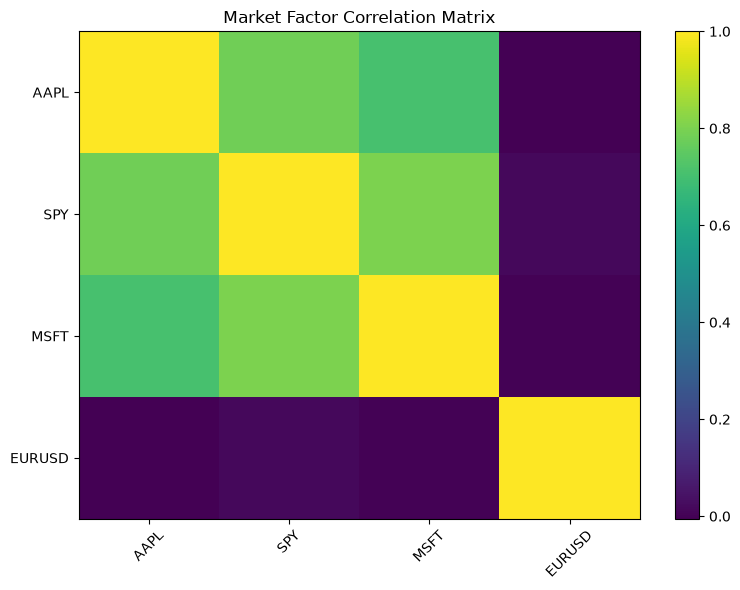

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "Market Factor Correlation Matrix"
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [29]:
annualized_volatility = (
    returns.std() * (252 ** 0.5)
)

annualized_volatility.sort_values(
    ascending=False
)

AAPL      0.318049
MSFT      0.296403
SPY       0.207655
EURUSD    0.076916
dtype: float64

In [30]:
market[
    ["US2Y", "US5Y", "US10Y"]
].describe()

,US2Y,US5Y,US10Y
count,1495.000000,1495.000000,1495.000000
mean,2.729057,2.743993,2.952107
std,1.863445,1.571135,1.407491
min,0.090000,0.190000,0.520000
25%,0.270000,0.880000,1.540000
50%,3.590000,3.590000,3.570000
75%,4.300000,4.060000,4.200000
max,5.190000,4.950000,4.980000
